# Bursa Smart Home Finder — Exploratory Data Analysis

Synthetic listings dataset (`data/raw/bursa_listings_synthetic.csv`) generated by `src/data_prep.py`, plus the neighborhood-level profile table (`data/processed/neighborhood_profiles_with_listing_stats.csv`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

DATA_DIR = Path("..") / "data"
listings = pd.read_csv(DATA_DIR / "raw" / "bursa_listings_synthetic.csv")
profiles = pd.read_csv(DATA_DIR / "processed" / "neighborhood_profiles_with_listing_stats.csv")

listings.shape, profiles.shape

((1200, 16), (8, 12))

In [2]:
listings.head()

,listing_id,neighborhood,district,room_type,size_m2,building_age,floor,total_floors,rent_try,distance_to_university_km,distance_to_center_km,distance_to_hospital_km,green_space_score,safety_score,public_transport_score,noise_level
0,1,Görükle,Nilüfer,3+1,124.8,20,1,7,14860.0,0.0,13.4,6.0,7.4,6.6,6.7,6.1
1,2,Görükle,Nilüfer,2+1,75.8,2,2,4,15840.0,0.0,15.0,5.3,6.7,6.7,5.9,6.5
2,3,Görükle,Nilüfer,3+1,128.1,2,0,7,18200.0,0.0,14.2,7.3,6.1,6.4,6.2,7.7
3,4,Görükle,Nilüfer,3+1,123.2,22,2,6,17170.0,3.3,14.2,5.0,4.9,7.5,7.2,6.3
4,5,Görükle,Nilüfer,1+1,48.6,2,8,9,9460.0,0.0,14.8,5.7,6.0,6.4,6.2,7.8


In [3]:
listings.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   listing_id                 1200 non-null   int64  
 1   neighborhood               1200 non-null   str    
 2   district                   1200 non-null   str    
 3   room_type                  1200 non-null   str    
 4   size_m2                    1200 non-null   float64
 5   building_age               1200 non-null   int64  
 6   floor                      1200 non-null   int64  
 7   total_floors               1200 non-null   int64  
 8   rent_try                   1200 non-null   float64
 9   distance_to_university_km  1200 non-null   float64
 10  distance_to_center_km      1200 non-null   float64
 11  distance_to_hospital_km    1200 non-null   float64
 12  green_space_score          1200 non-null   float64
 13  safety_score               1200 non-null   float64
 14  pub

In [4]:
listings.describe().T

,count,mean,std,min,25%,50%,75%,max
listing_id,1200.0,600.500000,346.554469,1.0,300.750,600.50,900.25,1200.0
size_m2,1200.0,90.848917,31.133196,45.0,64.875,85.60,111.80,169.9
building_age,1200.0,7.575833,8.154835,0.0,2.000,5.00,10.00,60.0
floor,1200.0,3.505000,2.628510,0.0,1.000,3.00,5.00,11.0
total_floors,1200.0,7.000833,2.564757,3.0,5.000,7.00,9.00,11.0
rent_try,1200.0,18555.900000,7825.973469,5120.0,12740.000,17190.00,22647.50,57250.0
distance_to_university_km,1200.0,8.912667,6.057360,0.0,4.800,8.20,11.10,26.5
distance_to_center_km,1200.0,8.203833,5.907027,0.0,4.200,6.80,11.50,23.7
distance_to_hospital_km,1200.0,3.982833,2.196701,0.0,2.400,3.75,5.30,9.9
green_space_score,1200.0,6.364250,1.472284,2.7,5.300,6.30,7.40,10.0


In [5]:
listings.isna().sum()

listing_id                   0
neighborhood                 0
district                     0
room_type                    0
size_m2                      0
building_age                 0
floor                        0
total_floors                 0
rent_try                     0
distance_to_university_km    0
distance_to_center_km        0
distance_to_hospital_km      0
green_space_score            0
safety_score                 0
public_transport_score       0
noise_level                  0
dtype: int64

## Rent distribution by neighborhood

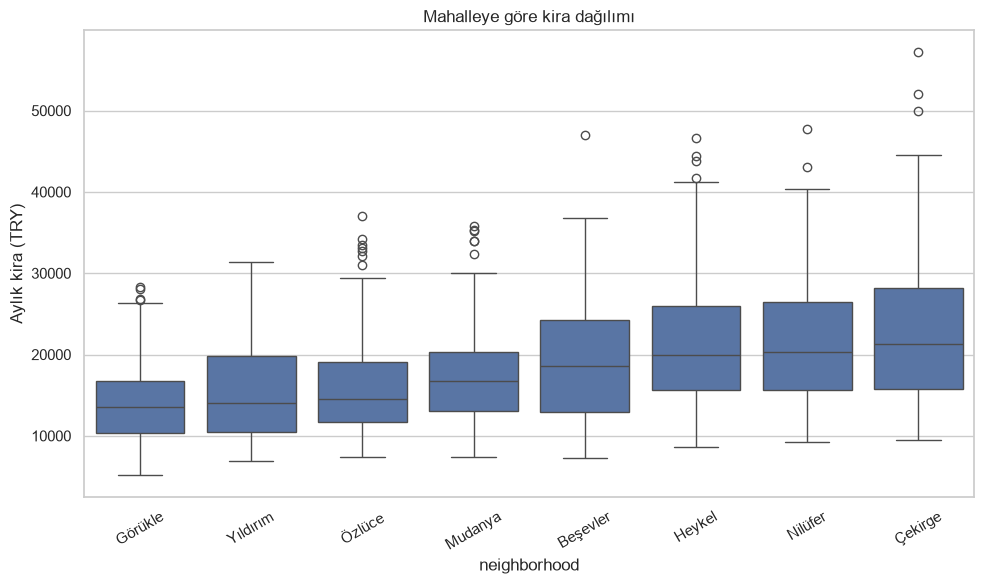

In [6]:
order = listings.groupby("neighborhood")["rent_try"].median().sort_values().index

plt.figure(figsize=(10, 6))
sns.boxplot(data=listings, x="neighborhood", y="rent_try", order=order)
plt.xticks(rotation=30)
plt.ylabel("Aylık kira (TRY)")
plt.title("Mahalleye göre kira dağılımı")
plt.tight_layout()
plt.show()

## Room type mix

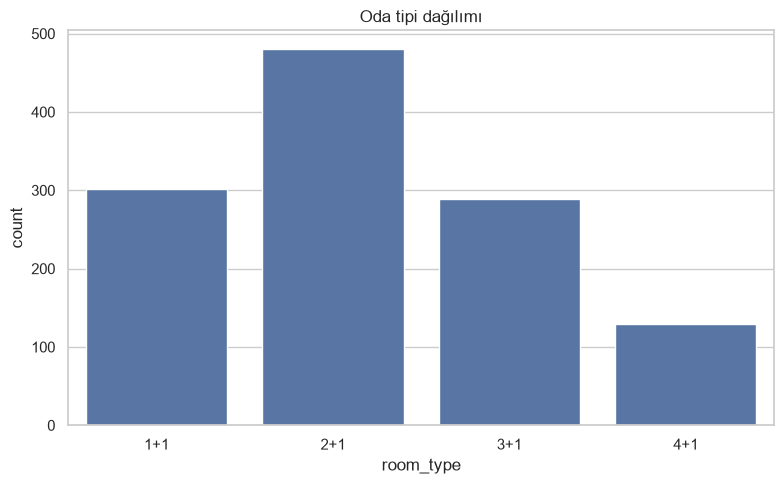

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=listings, x="room_type", order=["1+1", "2+1", "3+1", "4+1"])
plt.title("Oda tipi dağılımı")
plt.tight_layout()
plt.show()

## Neighborhood profile comparison

In [8]:
profile_cols = [
    "avg_rent_per_m2_try",
    "avg_distance_to_university_km",
    "avg_distance_to_center_km",
    "green_space_score",
    "safety_score",
    "public_transport_score",
    "noise_level",
]
profiles.set_index("neighborhood")[profile_cols]

,avg_rent_per_m2_try,avg_distance_to_university_km,avg_distance_to_center_km,green_space_score,safety_score,public_transport_score,noise_level
neighborhood,,,,,,,
Görükle,170,1.0,14.0,6.0,6.5,6.0,6.5
Özlüce,190,6.0,9.0,6.5,7.0,6.5,5.0
Beşevler,230,4.0,6.0,6.0,7.5,8.5,6.0
Nilüfer,260,7.5,7.0,7.5,8.0,7.5,4.5
Çekirge,280,9.0,3.0,7.0,8.5,7.0,5.0
Heykel,250,10.0,0.5,4.5,6.5,9.0,8.0
Yıldırım,175,12.0,6.0,5.0,6.0,6.0,6.0
Mudanya,210,22.0,20.0,8.5,7.5,4.0,3.0


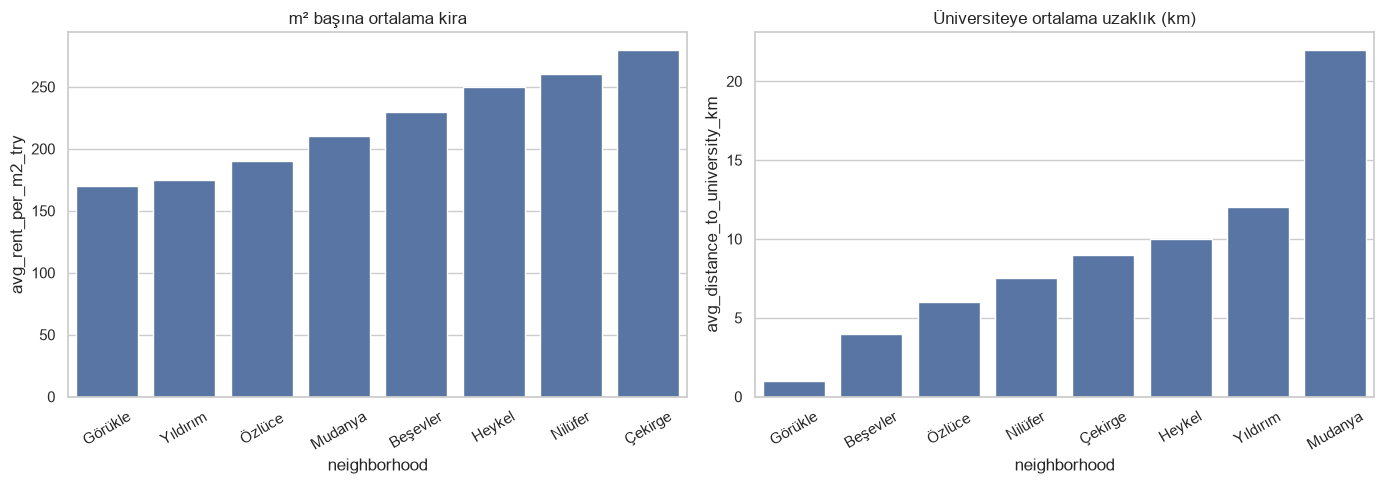

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sorted_by_price = profiles.sort_values("avg_rent_per_m2_try")
sns.barplot(data=sorted_by_price, x="neighborhood", y="avg_rent_per_m2_try", ax=axes[0])
axes[0].set_title("m² başına ortalama kira")
axes[0].tick_params(axis="x", rotation=30)

sorted_by_uni = profiles.sort_values("avg_distance_to_university_km")
sns.barplot(data=sorted_by_uni, x="neighborhood", y="avg_distance_to_university_km", ax=axes[1])
axes[1].set_title("Üniversiteye ortalama uzaklık (km)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Correlations between numeric features

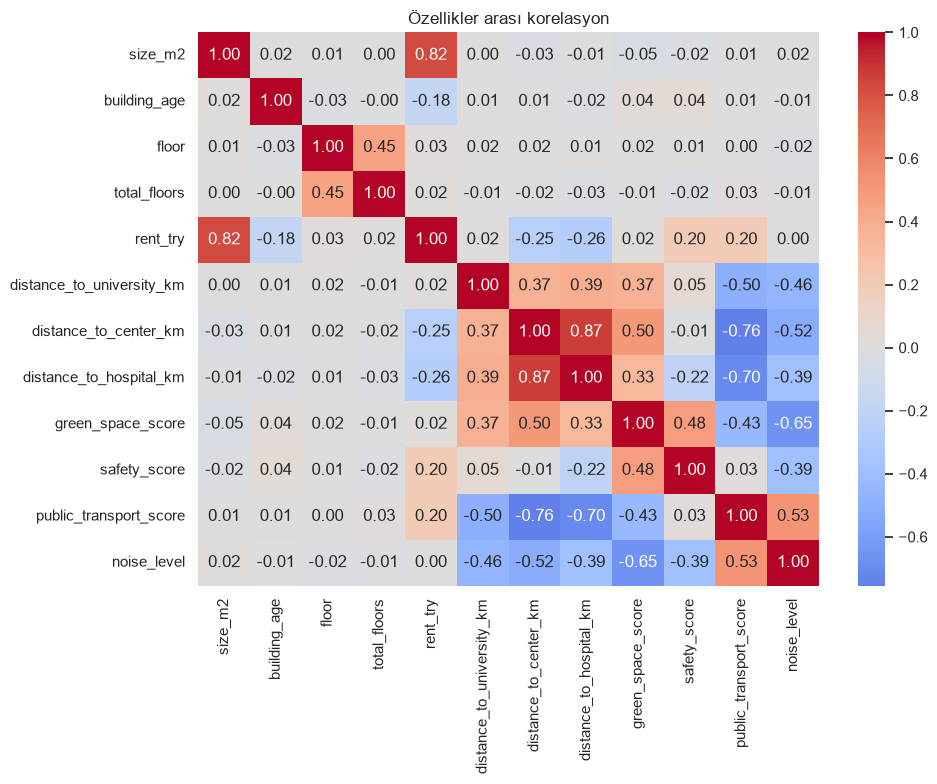

In [10]:
numeric_cols = listings.select_dtypes(include=[np.number]).drop(columns=["listing_id"])
corr = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Özellikler arası korelasyon")
plt.tight_layout()
plt.show()

## Price vs. distance to university

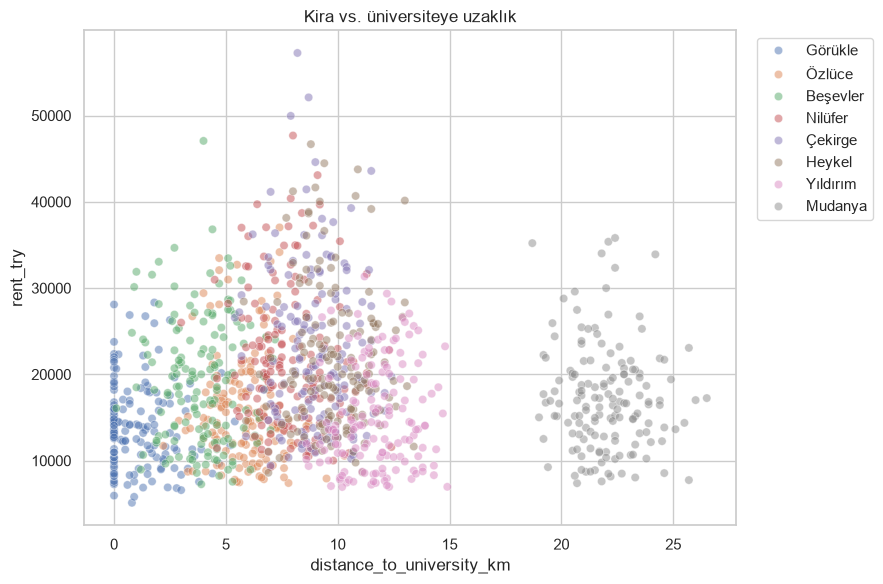

In [11]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=listings,
    x="distance_to_university_km",
    y="rent_try",
    hue="neighborhood",
    alpha=0.5,
)
plt.title("Kira vs. üniversiteye uzaklık")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Notes for feature engineering / scoring

- `rent_try` sağa çarpık (building_age ve size_m2 etkisiyle) — scoring için log dönüşümü veya bütçe eşiği bazlı normalize skor düşünülebilir.
- Mahalle bazlı `green_space_score`, `safety_score`, `public_transport_score`, `noise_level` doğrudan öncelik ağırlıklandırmasına (weighted scoring) girecek adaylar.
- `distance_to_university_km` ile `rent_try` arasında negatif ilişki (üniversiteye yakın ucuz — öğrenci bölgesi Görükle) dikkat çekici; öneri motorunda "öğrenciye uygunluk" gibi bir composite skor türetilebilir.
- Sıradaki adım: `src/` altında bir `feature_engineering.py` / scoring modülü ile mahalle profillerini kullanıcı önceliklerine göre ağırlıklandıran bir puanlama fonksiyonu yazmak.